#📌 Extracão

In [44]:
import requests
import pandas as pd

In [45]:
url =' https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data  = response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [46]:
df = pd.json_normalize(data)
df


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformação

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

1. Verificação valores unicos

In [48]:
for col in df.columns:
  print (f'{col}: {df[col].unique()}')
  if df[col].nunique()<50:
    print(df[col].unique())
    print('-'*50)

customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn: ['No' 'Yes' '']
['No' 'Yes' '']
--------------------------------------------------
customer.gender: ['Female' 'Male']
['Female' 'Male']
--------------------------------------------------
customer.SeniorCitizen: [0 1]
[0 1]
--------------------------------------------------
customer.Partner: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
customer.Dependents: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
customer.tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
phone.MultipleLines: ['No' 'Yes' 'No phone service']
['No' 'Yes' 'No phone service']
------

2.Valores Duplicados

In [49]:
print("Numero de duplicados",df.duplicated().sum())

Numero de duplicados 0


3.Valores Nulos

In [50]:
print('Numeros nulos \n', df.isnull().sum())

Numeros nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


4.Vazios ou em branco

In [51]:
df.apply(lambda x: (x.astype(str).str.strip() == '').sum())

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


TRANSFORMAÇÕES

1. Alterando a coluna "account.chargers.Total" para flot

In [52]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [53]:
df_plano = df[df['Churn'].str.strip() != '']
print('Número de filas depois de eliminar as vazias em "Churn":', len(df_plano))

Número de filas depois de eliminar as vazias em "Churn": 7043


2.Verificação de vazias ou em branco

In [54]:
df.apply(lambda x: (x.astype(str).str.strip() == '').sum())

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [55]:
print('Números nulos \n', df.isnull().sum())

Números nulos 
 customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


In [56]:
df_plano = df_plano.dropna(subset=['account.Charges.Total'])

In [57]:
print('Números nulos \n', df.isnull().sum())

Números nulos 
 customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


_______________________OPCIONAL

In [58]:
df['contas_diarias'] = df['account.Charges.Monthly'] / 30
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [60]:
colunas = {
 'customerID': 'id',
 'customer.gender': 'genero',
 'customer.SeniorCitizen': 'tem +60',
 'customer.Partner': 'possui_parceiro',
 'customer.Dependents': 'possui_dependentes',
 'customer.tenure': 'tempo_contrato',
 'phone.PhoneService': 'servico_telefone',
 'phone.MultipleLines': 'multiplas_linhas',
 'internet.InternetService': 'tipo_internet',
 'internet.OnlineSecurity': 'seguranca_online',
 'internet.OnlineBackup': 'backup_online',
 'internet.DeviceProtection': 'protecao_dispositivo',
 'internet.TechSupport': 'suporte_técnico',
 'internet.StreamingTV': 'streaming_tv',
 'internet.StreamingMovies': 'streaming_filmes',
 'account.Contract': 'tipo_contrato',
 'account.PaperlessBilling': 'fatura_digital',
 'account.PaymentMethod': 'metodo_pagamento',
 'account.Charges.Monthly': 'valor_mensal',
 'account.Charges.Total': 'total_cobrado'
}
df = df.rename(columns = colunas)
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_técnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [61]:
df['Churn'] = df['Churn'].replace({'No':'Não', 'Yes': 'Sim'})
df.head()

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_técnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,Não,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Sim,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Sim,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Sim,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [62]:
df['Churn'] = df['Churn'].replace({'No': 'Não', 'Yes': 'Sim'})

df['genero'] = df['genero'].replace({
    'Female': 'Feminino',
    'Male': 'Masculino'
})

df['possui_parceiro'] = df['possui_parceiro'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})

df['possui_dependentes'] = df['possui_dependentes'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})

df['servico_telefone'] = df['servico_telefone'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})

df['multiplas_linhas'] = df['multiplas_linhas'].replace({
    'No': 'Não',
    'Yes': 'Sim',
    'No phone service': 'Sem serviço de telefone'
})

df['tipo_internet'] = df['tipo_internet'].replace({
    'No': 'Não'
})

df.head()

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_técnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [63]:
df['tipo_contrato'] = df['tipo_contrato'].replace({
    'One year': 'Anual',
    'Month-to-month': 'Mensal',
    'Two year': 'Bienal'
})

In [64]:
df['tipo_contrato'] = df['tipo_contrato'].replace({
    'One year': 'Anual',
    'Month-to-month': 'Mensal',
    'Two year': 'Bienal'
})

In [65]:
df['fatura_digital'] = df['fatura_digital'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})

In [66]:
df['metodo_pagamento'] = df['metodo_pagamento'].replace({
    'Mailed check': 'Cheque enviado',
    'Electronic check': 'Cheque eletrônico',
    'Credit card (automatic)': 'Cartão de crédito (automático)',
    'Bank transfer (automatic)': 'Transferência bancária (automática)'
})

In [67]:
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_técnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,No,Yes,Yes,No,Anual,Sim,Cheque enviado,65.60,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,No,No,No,Yes,Mensal,Não,Cheque enviado,59.90,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Yes,No,No,No,Mensal,Sim,Cheque eletrônico,73.90,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Yes,No,Yes,Yes,Mensal,Sim,Cheque eletrônico,98.00,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,No,Yes,Yes,No,Mensal,Sim,Cheque enviado,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,Não,Feminino,0,Não,Não,13,Sim,Não,DSL,...,No,Yes,No,No,Anual,Não,Cheque enviado,55.15,742.90,1.838333
7263,9992-RRAMN,Sim,Masculino,0,Sim,Não,22,Sim,Sim,Fiber optic,...,No,No,No,Yes,Mensal,Sim,Cheque eletrônico,85.10,1873.70,2.836667
7264,9992-UJOEL,Não,Masculino,0,Não,Não,2,Sim,Não,DSL,...,No,No,No,No,Mensal,Sim,Cheque enviado,50.30,92.75,1.676667
7265,9993-LHIEB,Não,Masculino,0,Sim,Sim,67,Sim,Não,DSL,...,Yes,Yes,No,Yes,Bienal,Não,Cheque enviado,67.85,4627.65,2.261667


#📊 Carga e análise

1.Analise descristiva

In [68]:
df.describe()

,tem +60,tempo_contrato,valor_mensal,total_cobrado,contas_diarias
count,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.162653,32.346498,64.720098,2280.634213,2.157337
std,0.369074,24.571773,30.129572,2268.632997,1.004319
min,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.425000,400.225000,1.180833
50%,0.000000,29.000000,70.300000,1391.000000,2.343333
75%,0.000000,55.000000,89.875000,3785.300000,2.995833
max,1.000000,72.000000,118.750000,8684.800000,3.958333


2.Distribuição de Evasão

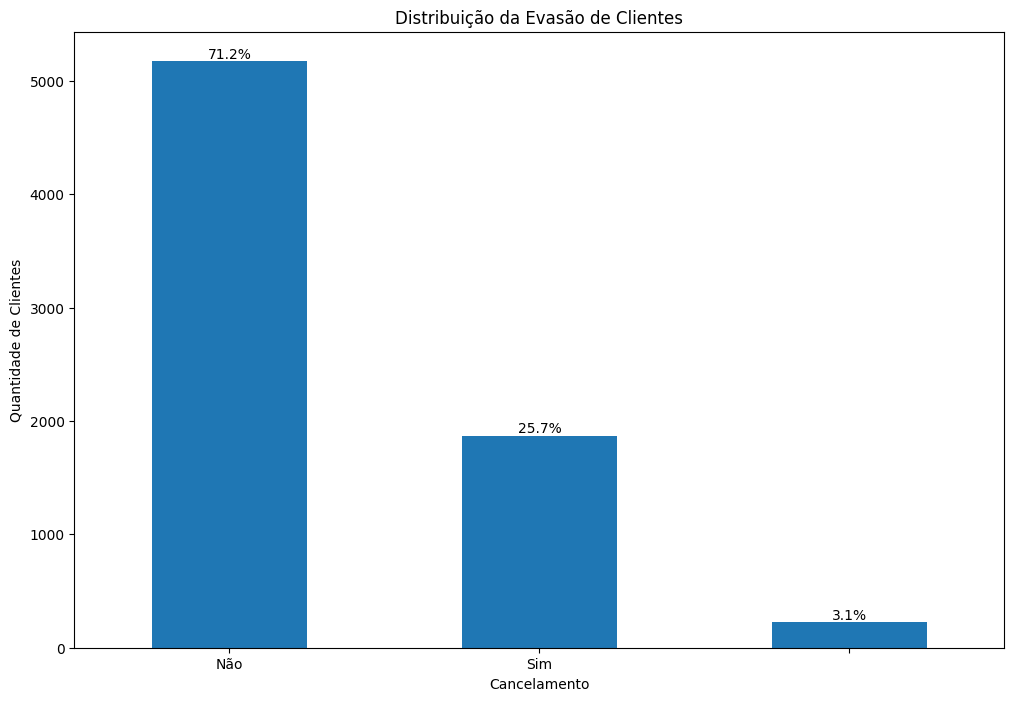

In [69]:




import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))


churn_counts = df['Churn'].value_counts()


churn_percent = churn_counts / churn_counts.sum() * 100


ax = churn_counts.plot(kind='bar')

plt.title('Distribuição da Evasão de Clientes')
plt.xlabel('Cancelamento')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=0)


for i in range(len(churn_counts)):
    ax.text(
        i,
        churn_counts.iloc[i],
        f'{churn_percent.iloc[i]:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

3.Contagem de Evsão por Variaveis Categorias

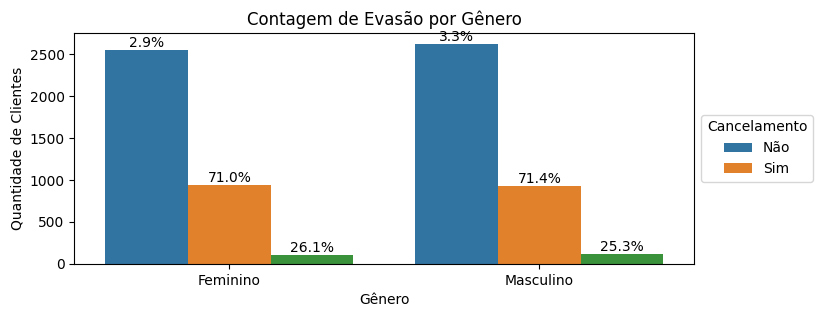

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(8, 3))

ax = sns.countplot(x='genero', hue='Churn', data=df)

plt.title('Contagem de Evasão por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Clientes')

plt.legend(title='Cancelamento', labels=['Não', 'Sim'],
           loc='center left', bbox_to_anchor=(1, 0.5))




total_por_genero = pd.crosstab(df['genero'], df['Churn'])
percentual = total_por_genero.div(total_por_genero.sum(axis=1), axis=0) * 100


for container in ax.containers:
    labels = []
    for bar in container:
        altura = bar.get_height()
        genero = bar.get_x() + bar.get_width() / 2


        x_index = int(round(bar.get_x()))
        hue_index = list(ax.containers).index(container)

        try:
            perc = percentual.iloc[x_index, hue_index]
            labels.append(f'{perc:.1f}%')
        except:
            labels.append('')

    ax.bar_label(container, labels=labels, label_type='edge')

plt.show()

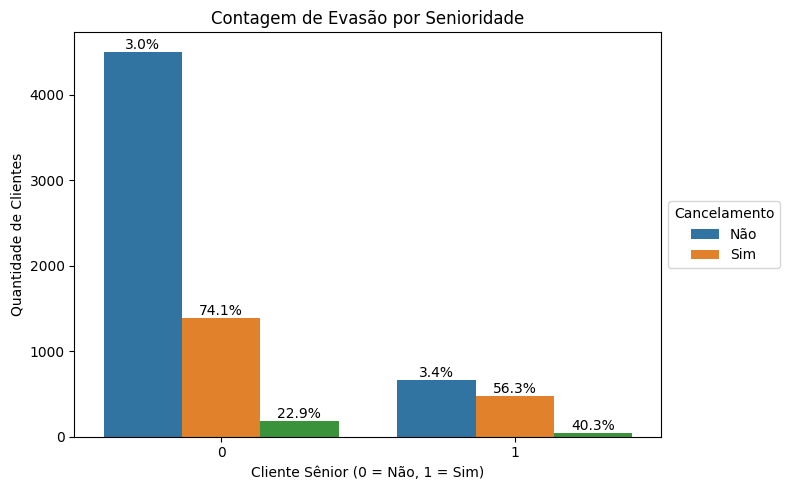

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(8, 5))

ax = sns.countplot(x='tem +60', hue='Churn', data=df)

plt.title('Contagem de Evasão por Senioridade')
plt.xlabel('Cliente Sênior (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Clientes')

plt.legend(title='Cancelamento',
           labels=['Não', 'Sim'],
           loc='center left',
           bbox_to_anchor=(1, 0.5))

# ===== CALCULAR PORCENTAGEM DENTRO DE CADA GRUPO =====

tabela = pd.crosstab(df['tem +60'], df['Churn'])
percentual = tabela.div(tabela.sum(axis=1), axis=0) * 100

# Inserir porcentagem nas barras
for i, container in enumerate(ax.containers):
    for j, bar in enumerate(container):
        altura = bar.get_height()

        # percentual correto por grupo
        perc = percentual.iloc[j, i]

        ax.text(
            bar.get_x() + bar.get_width()/2,
            altura,
            f'{perc:.1f}%',
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

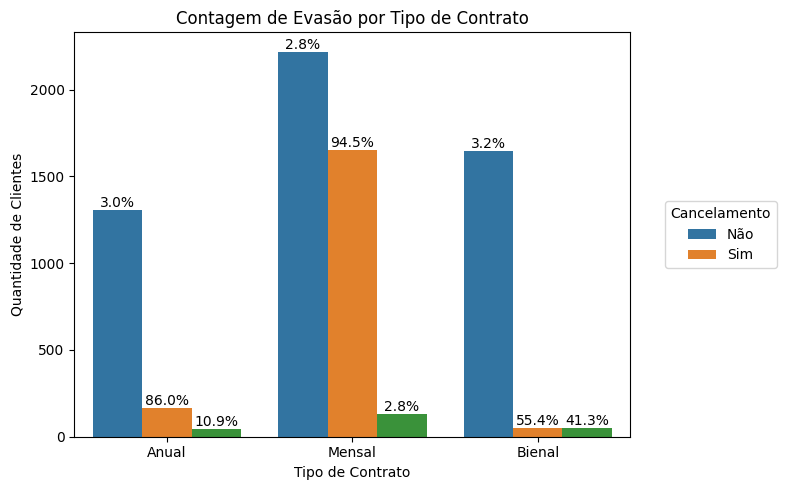

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(8,5))

ax = sns.countplot(x='tipo_contrato', hue="Churn", data=df)

plt.title('Contagem de Evasão por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')

plt.legend(title='Cancelamento',
           labels=['Não','Sim'],
           loc='center left',
           bbox_to_anchor=(1.05, 0.5))

# ===== CALCULAR PORCENTAGEM POR TIPO DE CONTRATO =====

tabela = pd.crosstab(df['tipo_contrato'], df['Churn'])
percentual = tabela.div(tabela.sum(axis=1), axis=0) * 100

# Inserir porcentagem nas barras
for i, container in enumerate(ax.containers):
    for j, bar in enumerate(container):
        altura = bar.get_height()
        perc = percentual.iloc[j, i]

        ax.text(
            bar.get_x() + bar.get_width()/2,
            altura,
            f'{perc:.1f}%',
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

In [73]:
import plotly.express as px

In [74]:
px.histogram(df, x="tempo_contrato", text_auto=True, color='Churn', barmode='group')

In [75]:
# Agrupar por tenure e Churn
df_grouped = df.groupby(['tempo_contrato', 'Churn']).size().unstack(fill_value=0)

# Calcular a % de churn por tenure
df_grouped['churn_rate'] = (df_grouped.get('Sim', 0) / df_grouped.sum(axis=1)) * 100

# Mostrar o resultado
print(df_grouped[['churn_rate']])

fig = px.line(df_grouped.reset_index(),
              x='tempo_contrato',
              y='churn_rate',
              markers=True,
              title='Taxa de Churn (%) por Tenure')

fig.show()

Churn           churn_rate
tempo_contrato            
0                 0.000000
1                59.936909
2                50.000000
3                45.410628
4                44.864865
...                    ...
68                8.653846
69                8.000000
70                9.016393
71                3.409091
72                1.626016

[73 rows x 1 columns]


In [76]:
px.histogram(df, x="metodo_pagamento", text_auto=True, color='Churn', barmode='group')

Tratamento e Limpeza (ETL)

In [77]:
df['total_cobrado'] = pd.to_numeric(df['total_cobrado'], errors='coerce')


df = df[df['Churn'] != ''].copy()


df.drop(columns=['id'], inplace=True, errors='ignore')


df['total_cobrado'] = df['total_cobrado'].fillna(0)

print("Check de dados nulos após limpeza:")
print(df.isnull().sum().sum())

Check de dados nulos após limpeza:
0


Encoding e Balanceamento

In [78]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd
import requests


url =' https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data  = response.json()
df = pd.json_normalize(data)

colunas = {
 'customerID': 'id',
 'customer.gender': 'genero',
 'customer.SeniorCitizen': 'tem +60',
 'customer.Partner': 'possui_parceiro',
 'customer.Dependents': 'possui_dependentes',
 'customer.tenure': 'tempo_contrato',
 'phone.PhoneService': 'servico_telefone',
 'phone.MultipleLines': 'multiplas_linhas',
 'internet.InternetService': 'tipo_internet',
 'internet.OnlineSecurity': 'seguranca_online',
 'internet.OnlineBackup': 'backup_online',
 'internet.DeviceProtection': 'protecao_dispositivo',
 'internet.TechSupport': 'suporte_técnico',
 'internet.StreamingTV': 'streaming_tv',
 'internet.StreamingMovies': 'streaming_filmes',
 'account.Contract': 'tipo_contrato',
 'account.PaperlessBilling': 'fatura_digital',
 'account.PaymentMethod': 'metodo_pagamento',
 'account.Charges.Monthly': 'valor_mensal',
 'account.Charges.Total': 'total_cobrado'
}
df = df.rename(columns = colunas)


df['total_cobrado'] = pd.to_numeric(df['total_cobrado'], errors='coerce')
df['total_cobrado'] = df['total_cobrado'].fillna(0)


df = df[df['Churn'].str.strip() != ''].copy()


df.drop(columns=['id'], inplace=True, errors='ignore')


df['Churn'] = df['Churn'].replace({'No': 'Não', 'Yes': 'Sim'})
df['genero'] = df['genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})
df['possui_parceiro'] = df['possui_parceiro'].replace({'Yes': 'Sim', 'No': 'Não'})
df['possui_dependentes'] = df['possui_dependentes'].replace({'Yes': 'Sim', 'No': 'Não'})
df['servico_telefone'] = df['servico_telefone'].replace({'Yes': 'Sim', 'No': 'Não'})
df['multiplas_linhas'] = df['multiplas_linhas'].replace({'No': 'Não', 'Yes': 'Sim', 'No phone service': 'Sem serviço de telefone'})
df['tipo_internet'] = df['tipo_internet'].replace({'No': 'Não'})
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensal', 'Two year': 'Bienal'})
df['fatura_digital'] = df['fatura_digital'].replace({'Yes': 'Sim', 'No': 'Não'})
df['metodo_pagamento'] = df['metodo_pagamento'].replace({
    'Mailed check': 'Cheque enviado',
    'Electronic check': 'Cheque eletrônico',
    'Credit card (automatic)': 'Cartão de crédito (automático)',
    'Bank transfer (automatic)': 'Transferência bancária (automática)'
})



df['Churn'] = df['Churn'].map({'Não': 0, 'Sim': 1})


df.dropna(subset=['Churn'], inplace=True)


df_final = pd.get_dummies(df, drop_first=True)


X = df_final.drop('Churn', axis=1)
y = df_final['Churn']


smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)


X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

print(f"Base balanceada: {y_res.value_counts(normalize=True)[1]*100:.2f}% de Churn")

Base balanceada: 50.00% de Churn


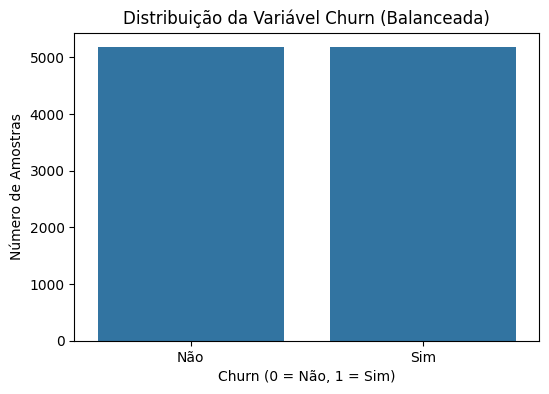

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=y_res)
plt.title('Distribuição da Variável Churn (Balanceada)')
plt.xlabel('Churn (0 = Não, 1 = Sim)')
plt.ylabel('Número de Amostras')
plt.xticks([0, 1], ['Não', 'Sim'])
plt.show()

Modelagem, Normalização e Avaliação


=== Avaliação: Regressão Logística ===
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1588
           1       0.82      0.84      0.83      1517

    accuracy                           0.83      3105
   macro avg       0.83      0.83      0.83      3105
weighted avg       0.83      0.83      0.83      3105



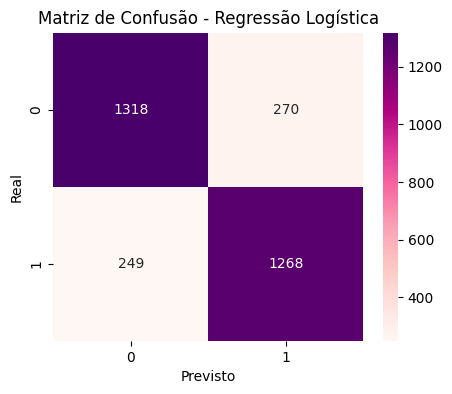


=== Avaliação: Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1588
           1       0.83      0.85      0.84      1517

    accuracy                           0.84      3105
   macro avg       0.84      0.84      0.84      3105
weighted avg       0.84      0.84      0.84      3105



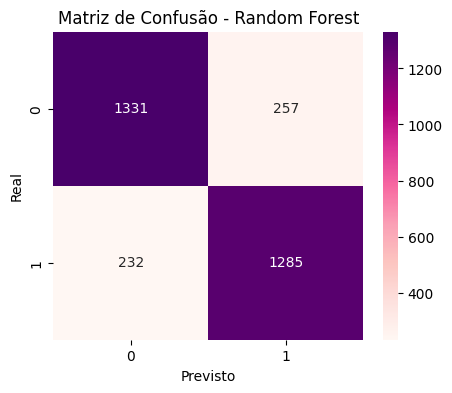

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Normalização (Essencial para modelos baseados em distância/coeficientes)
# O scaler deve ser ajustado apenas no treino para evitar vazamento de dados (data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Modelo: Regressão Logística
# Adicionamos max_iter=1000 para garantir que o modelo encontre a solução (convergência)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# 3. Modelo: Random Forest
# Modelos de árvore não são sensíveis à escala, então usamos os dados originais (X_train)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 4. Função de Avaliação (Conforme solicitado no Trello)
def exibir_metricas(y_true, y_pred, nome):
    print(f"\n=== Avaliação: {nome} ===")
    # Gera Precision, Recall, F1-score e Acurácia
    print(classification_report(y_true, y_pred))

    # Matriz de Confusão visual
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='RdPu')
    plt.title(f'Matriz de Confusão - {nome}')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

# Chamada das funções
exibir_metricas(y_test, y_pred_lr, "Regressão Logística")
exibir_metricas(y_test, y_pred_rf, "Random Forest")

Importância das Variáveis

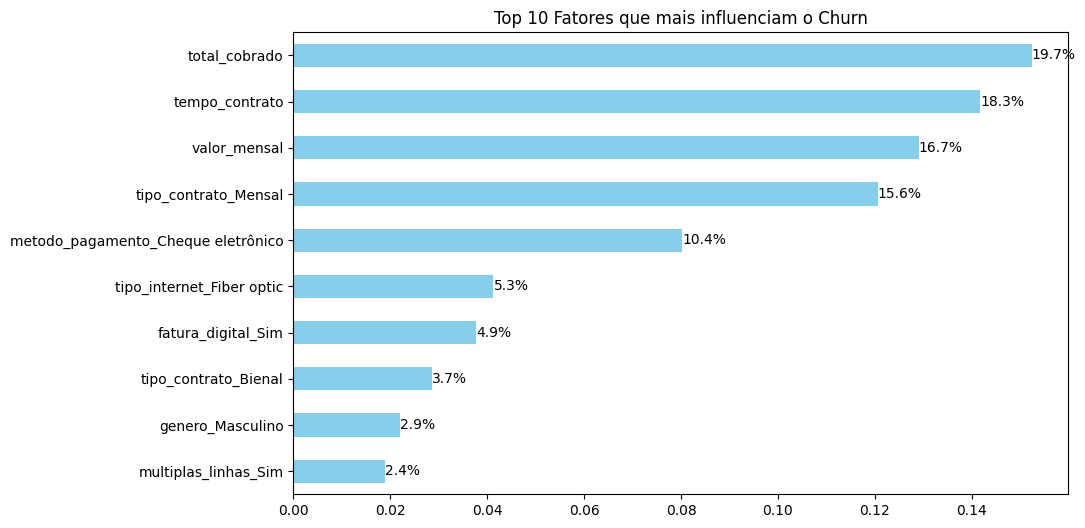

In [82]:

importancias = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))

top_10_importancias = importancias.head(10)
ax = top_10_importancias.plot(kind='barh', color='skyblue')
plt.title('Top 10 Fatores que mais influenciam o Churn')
plt.gca().invert_yaxis()


total_top_10 = top_10_importancias.sum()
for index, value in enumerate(top_10_importancias):
    percentage = (value / total_top_10) * 100
    ax.text(value, index, f'{percentage:.1f}%', va='center', ha='left')

plt.show()

#📄Relatorio Final

Principais Fatores que Afetam a Evasão (Insights)
A análise das variáveis mais importantes (Feature Importance) revelou os pilares que sustentam a decisão de cancelamento dos clientes:

Tipo de Contrato (Contract_Month-to-month): Este é o fator de maior impacto. Clientes com contratos mensais não possuem fidelidade contratual e apresentam taxas de evasão drasticamente superiores aos contratos anuais.

Tempo de Permanência (Tenure): Observou-se que o risco de Churn é crítico nos primeiros meses de relacionamento. Clientes "novos" ainda não criaram laços com a marca ou enfrentam dificuldades na curva de aprendizado do serviço.

Serviço de Internet (Fiber optic): Identificamos que o grupo de clientes de Fibra Óptica possui uma tendência maior de saída, sugerindo que o valor percebido do serviço pode estar abaixo do preço cobrado ou que há instabilidades técnicas específicas nesta tecnologia.

Encargos Mensais (Monthly Charges): Valores elevados sem benefícios claros de retenção correlacionam-se positivamente com o cancelamento